# SD-3.5 Diffusion-DPO v2 — shared pool (≥2500 images) + the `generated_v2` survey set

One consistent dataset, everything generated with the settings of the RufGen grid
(`IAA_Bias_05_Guitar_Aesthetics_2500.ipynb`): LoRA `merged_finetune/rw` (scale 1.0, fused),
the manifest prompt strings (trigger `Ruf Guitar Schrodinger 6`), **guidance 4.5**, 28 steps, 1024²,
CPU generator, survey seeds from `combinations.json` (`available_seeds`: 7, or 20 for 8 combos).

```
Dataset/RufGen/
  pool/                          178 prompts x K=16 = 2848 images (seeds 1000-1015) + scores.csv   [DPO data]
  pairs_v2/{rl_aes,rl_tech}/     preferences.jsonl per axis                                        [DPO data]
  generated_v2/plain/SD35/{color}/{top}/seed_XXXX.png              1350   reference (rw LoRA)
  generated_v2/generated_rl_aes/SD35/{color}/{top}/seed_XXXX.png   1350   rw + DPO aesthetic (NIMA + LAION)
  generated_v2/generated_rl_tech/SD35/{color}/{top}/seed_XXXX.png  1350   rw + DPO technical (MUSIQ + TOPIQ-NR)
```
Same layout as the catalogue / bucket, so `combinations.json` URLs map 1:1 (`generated` → `generated_v2/plain`).
LoRA weights go to `content/results/{rl_aes,rl_tech}/lora_v2`. The v1 folders (`generated/…`, plain LoRA,
catalogue token, guidance 7.0) are left untouched.

Order: **0 setup → 1 smoke → 2 what exists → 3 plain v2 (no DPO needed, ≈2.5 h) → 4 pool (≈5 h) → 5 pairs
→ 6 retrain (≈2–4 h/axis) → 7 curves → 8 reward gain → 9 rl_aes / rl_tech v2 (≈2.5 h each) → 10 look → 11 bucket**.
Every generation cell is resumable: rerun it after a runtime reset, existing files are skipped.

## 0. Setup — Drive, repo, deps

In [10]:
from google.colab import drive
drive.mount('/content/drive', force_remount=True)
import os, shutil, json, glob

DRIVE    = '/content/drive/MyDrive/Doktorat/content'
RESULTS  = f'{DRIVE}/results'
LORA     = f'{RESULTS}/merged_finetune/rw'                   # the LoRA of the RufGen grid (configs: plain_lora)
DATASET  = '/content/drive/MyDrive/Doktorat/Dokumetacja/reward-GENERATED/Dataset/RufGen'
POOL     = f'{DATASET}/pool'
PAIRS    = f'{DATASET}/pairs_v2'
MANIFEST = f'{DATASET}/tables/guitar_manifest.csv'           # exact prompts of the 1350 plain images
CATALOG  = f'{DATASET}/combinations.json'                    # 178 tasks, available_seeds per task
GEN      = f'{DATASET}/generated'                            # v1 + the original grid: generated/<method>/SD35/...
GEN2     = f'{DATASET}/generated_v2'                         # v2: generated_v2/<method>/SD35/{color}/{top}/seed_XXXX.png
METHODS  = ['plain', 'generated_rl_aes', 'generated_rl_tech']
STEPS, GUIDANCE = 28, 4.5                                    # RufGen grid settings
for m in METHODS:
    os.makedirs(f'{GEN2}/{m}', exist_ok=True)

# repo: prefer the Drive copy (has the v2 code), fall back to GitHub
REPO_SRC = '/content/drive/MyDrive/Doktorat/Dokumetacja/reward-GENERATED/code/sd35-dpo'
REPO_URL = 'https://github.com/lpopek/SD3.5-DPO'
REPO = '/content/sd35-dpo'
shutil.rmtree(REPO, ignore_errors=True)
if os.path.exists(f'{REPO_SRC}/scripts/build_pool.py'):
    shutil.copytree(REPO_SRC, REPO, ignore=shutil.ignore_patterns('.git', '__pycache__', '.DS_Store'))
    print('repo copied from Drive')
else:
    !git clone -q {REPO_URL} {REPO}
    assert os.path.exists(f'{REPO}/scripts/build_pool.py'), 'GitHub copy has no v2 code — push the repo first'
%cd {REPO}

# point the configs at this Drive layout (idempotent)
!sed -i "s#^plain_lora:.*#plain_lora: {LORA}#; s#^pool_dir:.*#pool_dir: {POOL}#; s#^manifest:.*#manifest: {MANIFEST}#" configs/pool.yaml
for ax, d in [('aesthetic', 'rl_aes'), ('technical', 'rl_tech')]:
    !sed -i "s#^plain_lora:.*#plain_lora: {LORA}#; s#^  pool_dir:.*#  pool_dir: {POOL}#; s#^  out_dir:.*#  out_dir: {PAIRS}/{d}#" configs/{ax}.yaml
!grep -hE "^(plain_lora|pool_dir|manifest|gen_guidance|k_per_prompt|base_seed):" configs/pool.yaml

for name, path in [('rw LoRA', f'{LORA}/pytorch_lora_weights.safetensors'), ('manifest', MANIFEST), ('catalog', CATALOG)]:
    print(('OK      ' if os.path.exists(path) else 'MISSING ') + f'{name}: {path}')

Mounted at /content/drive
repo copied from Drive
/content/sd35-dpo
plain_lora: /content/drive/MyDrive/Doktorat/content/results/merged_finetune/rw
manifest: /content/drive/MyDrive/Doktorat/Dokumetacja/reward-GENERATED/Dataset/RufGen/tables/guitar_manifest.csv
pool_dir: /content/drive/MyDrive/Doktorat/Dokumetacja/reward-GENERATED/Dataset/RufGen/pool
k_per_prompt: 16
base_seed: 1000          # keep away from survey seeds 0-19 and reward_gain seeds 100+
gen_guidance: 4.5          # RufGen grid used 4.5 (v1 pairs used 7.0)
OK      rw LoRA: /content/drive/MyDrive/Doktorat/content/results/merged_finetune/rw/pytorch_lora_weights.safetensors
OK      manifest: /content/drive/MyDrive/Doktorat/Dokumetacja/reward-GENERATED/Dataset/RufGen/tables/guitar_manifest.csv
OK      catalog: /content/drive/MyDrive/Doktorat/Dokumetacja/reward-GENERATED/Dataset/RufGen/combinations.json


In [11]:
!nvidia-smi -L
!pip install -q -r requirements.txt
!pip uninstall -y -q torchao 2>/dev/null
from huggingface_hub import login
from google.colab import userdata
login(userdata.get('HF_TOKEN'))

GPU 0: NVIDIA A100-SXM4-40GB (UUID: GPU-6ec4da6e-2068-03ca-45fb-ef0be52e3def)


## 1. CPU smoke tests (no downloads)

In [12]:
!python tests/test_pool_pairs.py
!python tests/smoke_tiny.py

[pool] /tmp/sd35dpo_pool__v7_i8av/rl_aes/pairs: copied 40 images
[pool] grid 5 prompts x K=16 = 80 images; 40 present, 40 to generate -> /tmp/sd35dpo_pool__v7_i8av/pool
[pool] grid 5 prompts x K=16 = 80 images; 80 present, 0 to generate -> /tmp/sd35dpo_pool__v7_i8av/pool
[score] pool 80 images on disk (0 of the grid missing), 0 cached, 80 to score: ['nima', 'laion_aes', 'musiq', 'topiq_nr', 'clipiqa']
[score] 70/80
[score] 80/80
[score] 80 rows -> /tmp/sd35dpo_pool__v7_i8av/pool/scores.csv
[pool] grid 5 prompts x K=20 = 100 images; 80 present, 20 to generate -> /tmp/sd35dpo_pool__v7_i8av/pool
[score] pool 100 images on disk (0 of the grid missing), 80 cached, 20 to score: ['nima', 'laion_aes', 'musiq', 'topiq_nr', 'clipiqa']
[score] 20/20
[score] 100 rows -> /tmp/sd35dpo_pool__v7_i8av/pool/scores.csv
summary: {"strategy": "top_bottom", "margin": 0.0, "max_pairs_per_prompt": 8, "min_rank_gap": 1, "n_images_scored": 100, "n_prompts": 5, "k_per_prompt": {"20": 5}, "n_pairs": 40, "n_images

## 2. What already exists on Drive

Expected when everything is done: `generated/plain/SD35` 1350 (original grid), v1 folders 1246 each
(plain LoRA, catalogue token, guidance 7.0 — reference only), `generated_v2/*` 1350 each, `pool` 2848.

In [13]:
def count_png(d):
    return len(glob.glob(f'{d}/**/*.png', recursive=True)) if os.path.exists(d) else None
rows = [('generated/plain/SD35 (original grid)', f'{GEN}/plain/SD35'),
        ('generated/generated_rl_aes (v1)', f'{GEN}/generated_rl_aes'),
        ('generated/generated_rl_tech (v1)', f'{GEN}/generated_rl_tech')]
rows += [(f'generated_v2/{m}', f'{GEN2}/{m}') for m in METHODS] + [('pool/images', f'{POOL}/images')]
for name, d in rows:
    print(f'{name:40s} {count_png(d)}')
sc = f'{POOL}/scores.csv'
print(f'{"pool scored rows":40s} {sum(1 for _ in open(sc)) - 1 if os.path.exists(sc) else 0}')
n_survey = sum(len(t['meta']['available_seeds']) for t in json.load(open(CATALOG))['tasks'])
print('catalogue: 178 tasks,', n_survey, 'images per method')

generated/plain/SD35 (original grid)     None
generated/generated_rl_aes (v1)          1246
generated/generated_rl_tech (v1)         1246
generated_v2/plain                       0
generated_v2/generated_rl_aes            0
generated_v2/generated_rl_tech           0
pool/images                              None
pool scored rows                         0
catalogue: 178 tasks, 1350 images per method


## 3. `generated_v2/plain` — the reference set (no DPO needed, run first)

rw LoRA fused, manifest prompts, guidance 4.5, seeds = `available_seeds` of each task (1350 images ≈ 2.5 h).
Regenerated rather than copied from `generated/plain/SD35` so that all three methods share one code path
(fused LoRA, same diffusers version). Smoke with `--limit 2` first.

In [14]:
!python eval/generate_triplets.py --method plain --catalog {CATALOG} --manifest {MANIFEST} \
    --plain-lora {LORA} --out {GEN2}/plain --no-suffix --steps {STEPS} --guidance {GUIDANCE} --limit 2

[triplets] prompts from manifest (178 color/top combos)
/usr/local/lib/python3.13/dist-packages/diffusers/utils/deprecation_utils.py:23: FutureWarning: `torch_dtype` is deprecated and will be removed in version 1.0.0. Please use `dtype` instead.
  deprecate("torch_dtype", "1.0.0", _TORCH_DTYPE_DEPRECATION_MESSAGE)
Loading pipeline components...:   0% 0/9 [00:00<?, ?it/s]
Loading weights:   0% 0/517 [00:00<?, ?it/s]
Loading weights:  32% 168/517 [00:00<00:00, 1674.61it/s]
Loading weights: 100% 517/517 [00:00<00:00, 1772.83it/s]
Loading pipeline components...:  22% 2/9 [00:00<00:02,  3.21it/s]
Loading weights:   0% 0/219 [00:00<?, ?it/s]
Loading weights:   7% 16/219 [00:00<00:01, 120.67it/s]
Loading weights:  15% 32/219 [00:00<00:01, 128.72it/s]
Loading weights:  21% 45/219 [00:00<00:01, 126.95it/s]
Loading weights:  27% 59/219 [00:00<00:01, 128.06it/s]
Loading weights:  33% 72/219 [00:00<00:01, 121.91it/s]
Loading weights:  40% 88/219 [00:00<00:01, 126.73it/s]
Loading weights:  47% 102/

In [15]:
!python eval/generate_triplets.py --method plain --catalog {CATALOG} --manifest {MANIFEST} \
    --plain-lora {LORA} --out {GEN2}/plain --no-suffix --steps {STEPS} --guidance {GUIDANCE}

[triplets] prompts from manifest (178 color/top combos)
/usr/local/lib/python3.13/dist-packages/diffusers/utils/deprecation_utils.py:23: FutureWarning: `torch_dtype` is deprecated and will be removed in version 1.0.0. Please use `dtype` instead.
  deprecate("torch_dtype", "1.0.0", _TORCH_DTYPE_DEPRECATION_MESSAGE)
Loading pipeline components...:   0% 0/9 [00:00<?, ?it/s]
Loading weights: 100% 197/197 [00:00<00:00, 2542.08it/s]
Loading pipeline components...:  22% 2/9 [00:00<00:01,  5.35it/s]
Loading weights:   0% 0/517 [00:00<?, ?it/s]
Loading weights:  29% 152/517 [00:00<00:00, 1509.39it/s]
Loading weights:  59% 307/517 [00:00<00:00, 1533.07it/s]
Loading weights: 100% 517/517 [00:00<00:00, 1595.64it/s]
Loading pipeline components...:  67% 6/9 [00:01<00:00,  7.09it/s]
Loading weights:   0% 0/219 [00:00<?, ?it/s]
Loading weights:   6% 13/219 [00:00<00:01, 129.05it/s]
Loading weights:  12% 26/219 [00:00<00:01, 101.75it/s]
Loading weights:  19% 41/219 [00:00<00:01, 120.55it/s]
Loading wei

## 4. Pool — seeds 1000–1015 for every manifest prompt, scored on both axes

Resumable: only missing images are generated, only unscored images are scored.
2848 images ≈ 4.5–5 h, scoring ≈ 15–25 min. Smoke with `--limit 2` (32 images).

In [16]:
!python scripts/build_pool.py --config configs/pool.yaml --limit 2

[pool] 178 unique prompts from manifest /content/drive/MyDrive/Doktorat/Dokumetacja/reward-GENERATED/Dataset/RufGen/tables/guitar_manifest.csv
pool=/content/drive/MyDrive/Doktorat/Dokumetacja/reward-GENERATED/Dataset/RufGen/pool  prompts=178  K=16  seeds=1000..1015
/usr/local/lib/python3.13/dist-packages/diffusers/utils/deprecation_utils.py:23: FutureWarning: `torch_dtype` is deprecated and will be removed in version 1.0.0. Please use `dtype` instead.
  deprecate("torch_dtype", "1.0.0", _TORCH_DTYPE_DEPRECATION_MESSAGE)
Loading pipeline components...:  22% 2/9 [00:00<00:00, 11.69it/s]
Loading weights:   0% 0/219 [00:00<?, ?it/s]
Loading weights:   7% 16/219 [00:00<00:01, 117.78it/s]
Loading weights:  15% 32/219 [00:00<00:01, 137.63it/s]
Loading weights:  21% 47/219 [00:00<00:01, 133.59it/s]
Loading weights:  28% 61/219 [00:00<00:01, 121.15it/s]
Loading weights:  35% 77/219 [00:00<00:01, 132.27it/s]
Loading weights:  42% 91/219 [00:00<00:01, 114.07it/s]
Loading weights:  49% 107/219 [00

In [17]:
!python scripts/build_pool.py --config configs/pool.yaml

Streaming output truncated to the last 5000 lines.
[pool] 338/2816 images/p023_g1.png  (prompt 23: Ruf Guitar Schrodinger 6, a single-cutaway el...)
100% 28/28 [00:05<00:00,  5.37it/s]
[pool] 339/2816 images/p023_g2.png  (prompt 23: Ruf Guitar Schrodinger 6, a single-cutaway el...)
100% 28/28 [00:05<00:00,  5.36it/s]
[pool] 340/2816 images/p023_g3.png  (prompt 23: Ruf Guitar Schrodinger 6, a single-cutaway el...)
100% 28/28 [00:05<00:00,  5.37it/s]
[pool] 341/2816 images/p023_g4.png  (prompt 23: Ruf Guitar Schrodinger 6, a single-cutaway el...)
100% 28/28 [00:05<00:00,  5.37it/s]
[pool] 342/2816 images/p023_g5.png  (prompt 23: Ruf Guitar Schrodinger 6, a single-cutaway el...)
100% 28/28 [00:05<00:00,  5.36it/s]
[pool] 343/2816 images/p023_g6.png  (prompt 23: Ruf Guitar Schrodinger 6, a single-cutaway el...)
100% 28/28 [00:05<00:00,  5.36it/s]
[pool] 344/2816 images/p023_g7.png  (prompt 23: Ruf Guitar Schrodinger 6, a single-cutaway el...)
100% 28/28 [00:05<00:00,  5.36it/s]
[pool] 345/

In [18]:
import pandas as pd
sc = pd.read_csv(f'{POOL}/scores.csv')
print(json.load(open(f'{POOL}/meta.json')))
print(len(sc), 'scored images;', sc.groupby('prompt_idx').size().value_counts().to_dict(), '(K per prompt: count)')
sc[['nima', 'laion_aes', 'musiq', 'topiq_nr']].describe().T

{'k': 16, 'n_prompts': 178, 'base_seed': 1000, 'steps': 28, 'guidance': 4.5, 'size': 1024}
2848 scored images; {16: 178} (K per prompt: count)


,count,mean,std,min,25%,50%,75%,max
nima,2848.0,5.202748,0.284708,4.29054,5.005373,5.195635,5.393388,6.21811
laion_aes,2848.0,5.683770,0.184056,4.92674,5.560475,5.697680,5.807595,6.19478
musiq,2848.0,73.358827,3.172025,60.00721,71.499493,74.191735,75.824678,78.16109
topiq_nr,2848.0,0.665372,0.032366,0.55469,0.640912,0.665210,0.689142,0.74573


## 5. Pairs per axis (CPU, seconds)

Default = the paper's top-vs-bottom ladder, 8 rungs over K=16 (≤ 8 pairs/prompt, ≤ 1424 pairs).
`ranked_gap` (rank gap ≥ 4, ≤ 16 pairs/prompt) gives up to 2848 pairs — pick one and state it in the methods.

In [19]:
for ax in ['aesthetic', 'technical']:
    !python scripts/build_pairs.py --config configs/{ax}.yaml --min-pairs 1000
# denser alternative into a separate folder:
# !python scripts/build_pairs.py --config configs/aesthetic.yaml --strategy ranked_gap --max-pairs 16 --min-rank-gap 4 --out {PAIRS}/rl_aes_ranked_gap
for ax, d in [('aesthetic', 'rl_aes'), ('technical', 'rl_tech')]:
    s = json.load(open(f'{PAIRS}/{d}/summary.json'))
    print(ax, {k: s[k] for k in ['n_images_scored', 'n_pairs', 'n_images_in_pairs', 'margin_mean', 'margin_min', 'pairs_per_prompt', 'degenerate_mad_prompts']})

axis=aesthetic metrics=['nima', 'laion_aes']
{
 "strategy": "top_bottom",
 "margin": 0.1,
 "max_pairs_per_prompt": 8,
 "min_rank_gap": 4,
 "n_images_scored": 2848,
 "n_prompts": 178,
 "k_per_prompt": {
  "16": 178
 },
 "n_pairs": 1312,
 "n_images_in_pairs": 2624,
 "prompts_with_pairs": 178,
 "pairs_per_prompt": {
  "6": 7,
  "7": 98,
  "8": 73
 },
 "margin_mean": 1.5107880965838487,
 "margin_median": 1.2295760363340378,
 "margin_min": 0.10044579207897186,
 "margin_max": 9.407150745391846,
 "degenerate_mad_prompts": {}
}
-> /content/drive/MyDrive/Doktorat/Dokumetacja/reward-GENERATED/Dataset/RufGen/pairs_v2/rl_aes/preferences.jsonl
axis=technical metrics=['musiq', 'topiq_nr']
{
 "strategy": "top_bottom",
 "margin": 0.1,
 "max_pairs_per_prompt": 8,
 "min_rank_gap": 4,
 "n_images_scored": 2848,
 "n_prompts": 178,
 "k_per_prompt": {
  "16": 178
 },
 "n_pairs": 1330,
 "n_images_in_pairs": 2660,
 "prompts_with_pairs": 178,
 "pairs_per_prompt": {
  "6": 4,
  "7": 86,
  "8": 88
 },
 "margin_me

## 6. Train the DPO adapters (`lora_v2`, ≈ 2–4 h per axis)

Reference = rw LoRA fused (identical to the plain set). With ~1400 pairs and 500 steps every pair is
seen ≈ 1.4× (v1: 5.6×) — `--max-steps 1000` is a reasonable alternative.

In [20]:
for ax, d in [('aesthetic', 'rl_aes'), ('technical', 'rl_tech')]:
    !python scripts/run_pipeline.py --config configs/{ax}.yaml \
        --pairs {PAIRS}/{d}/preferences.jsonl --run-name lora_v2

axis=aesthetic  metrics=['nima', 'laion_aes']  out=/content/drive/MyDrive/Doktorat/content/results/rl_aes  pairs=/content/drive/MyDrive/Doktorat/Dokumetacja/reward-GENERATED/Dataset/RufGen/pairs_v2/rl_aes/preferences.jsonl
DPO: beta=100.0 lr=2.56e-06 eff_batch=4 steps=500 -> /content/drive/MyDrive/Doktorat/content/results/rl_aes/lora_v2
dataset: 1312 pairs over 178 prompts; reward margin mean=1.511 min=0.100 max=9.407
/usr/local/lib/python3.13/dist-packages/diffusers/utils/deprecation_utils.py:23: FutureWarning: `torch_dtype` is deprecated and will be removed in version 1.0.0. Please use `dtype` instead.
  deprecate("torch_dtype", "1.0.0", _TORCH_DTYPE_DEPRECATION_MESSAGE)
Loading pipeline components...:  11% 1/9 [00:00<00:01,  6.01it/s]
Loading weights: 100% 197/197 [00:00<00:00, 2918.90it/s]
Loading pipeline components...:  22% 2/9 [00:00<00:01,  5.64it/s]
Loading weights:   0% 0/219 [00:00<?, ?it/s]
Loading weights:   7% 16/219 [00:00<00:01, 111.05it/s]
Loading weights:  16% 34/219 

## 7. Training curves

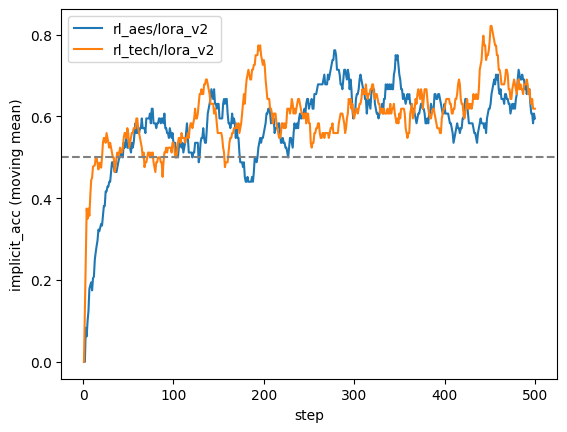

In [21]:
import matplotlib.pyplot as plt
for d in ['rl_aes', 'rl_tech']:
    p = f'{RESULTS}/{d}/lora_v2/train_log.json'
    if not os.path.exists(p): continue
    h = json.load(open(p))['history']; w = 20
    acc = [sum(x['implicit_acc'] for x in h[max(0, i-w):i+1]) / len(h[max(0, i-w):i+1]) for i in range(len(h))]
    plt.plot([x['step'] for x in h], acc, label=f'{d}/lora_v2')
plt.axhline(0.5, ls='--', c='gray'); plt.legend(); plt.xlabel('step'); plt.ylabel('implicit_acc (moving mean)'); plt.show()

## 8. Does the adapter move anything? Reward gain + sweep

`lora_v2` (β=100, LR 2.56e-6, 500 steps) learns in the right direction (`implicit_acc` ≈ 0.6–0.7) but the
shift is tiny — the triplets look identical. Before generating 2700 survey images, measure the gain on the
adapter's own axis on held-out seeds and try stronger settings. Everything below is optional and independent;
each variant writes its own folder and `report.json`.

| variant | what changes | cost |
|---|---|---|
| `lora_v2` × scale 1 / 2 / 3 | inference-time adapter strength (no training) | ≈ 10 min each |
| `lora_v2_cont` | continue `lora_v2` for +1500 steps (same β / LR) | ≈ 2 h / axis |
| `lora_v2_b10` | β = 10, LR 1e-5, 1000 steps from scratch (weaker KL anchor) | ≈ 1.5 h / axis |

In [ ]:
# 8a. reward gain of lora_v2 at adapter scale 1 / 2 / 3 (no training; 20 prompts x 3 seeds = 120 images per arm)
for ax, d in [('aesthetic', 'rl_aes'), ('technical', 'rl_tech')]:
    for scale in [1.0, 2.0, 3.0]:
        !python eval/reward_gain.py --config configs/{ax}.yaml --dpo-lora {RESULTS}/{d}/lora_v2 --dpo-scale {scale} \
            --prompts {POOL}/prompts.txt --n-prompts 20 --seeds 100-102 --steps {STEPS} --guidance {GUIDANCE} \
            --out {RESULTS}/{d}/eval_lora_v2_x{int(scale)}

In [ ]:
# 8b. continue lora_v2 (+1500 steps, same hyper-parameters)
for ax, d in [('aesthetic', 'rl_aes'), ('technical', 'rl_tech')]:
    !python scripts/run_pipeline.py --config configs/{ax}.yaml --pairs {PAIRS}/{d}/preferences.jsonl \
        --init-lora {RESULTS}/{d}/lora_v2 --max-steps 1500 --run-name lora_v2_cont

In [ ]:
# 8c. weaker KL anchor: beta 10, LR 1e-5, 1000 steps from scratch
for ax, d in [('aesthetic', 'rl_aes'), ('technical', 'rl_tech')]:
    !python scripts/run_pipeline.py --config configs/{ax}.yaml --pairs {PAIRS}/{d}/preferences.jsonl \
        --beta 10 --lr 1e-5 --max-steps 1000 --run-name lora_v2_b10

In [ ]:
# 8d. reward gain of the trained variants
for ax, d in [('aesthetic', 'rl_aes'), ('technical', 'rl_tech')]:
    for run in ['lora_v2_cont', 'lora_v2_b10']:
        if os.path.exists(f'{RESULTS}/{d}/{run}/pytorch_lora_weights.safetensors'):
            !python eval/reward_gain.py --config configs/{ax}.yaml --dpo-lora {RESULTS}/{d}/{run} \
                --prompts {POOL}/prompts.txt --n-prompts 20 --seeds 100-102 --steps {STEPS} --guidance {GUIDANCE} \
                --out {RESULTS}/{d}/eval_{run}

In [ ]:
# 8e. comparison table: mean gain per metric and pairwise win-rate (policy > plain on the same prompt+seed)
import pandas as pd
rows = []
for d in ['rl_aes', 'rl_tech']:
    for ev in sorted(glob.glob(f'{RESULTS}/{d}/eval_*/report.json')):
        r = json.load(open(ev)); run = os.path.basename(os.path.dirname(ev)).replace('eval_', '')
        for metric, v in r.items():
            if metric.startswith('_') or 'win_rate' not in v: continue
            rows.append(dict(axis=d, run=run, metric=metric, plain=round(v['mean_plain'], 3),
                             policy=round(v['mean_policy'], 3), gain=round(v['mean_gain'], 3), win_rate=round(v['win_rate'], 2)))
df = pd.DataFrame(rows)
display(df.pivot_table(index=['axis', 'run'], columns='metric', values=['gain', 'win_rate']))
# win_rate ~0.5 and gain ~0 => the adapter does nothing visible; pick the variant with the largest gain
# on its OWN axis and set BEST below before section 9

In [ ]:
BEST = {'rl_aes': 'lora_v2', 'rl_tech': 'lora_v2'}     # e.g. {'rl_aes': 'lora_v2_b10', ...}
BEST_SCALE = 1.0                                          # e.g. 2.0 if the scale ablation wins

## 9. `generated_v2/generated_rl_aes` and `generated_rl_tech` — the survey sets

Same prompt, seeds and sampler as `generated_v2/plain`; the DPO adapter (`BEST`, `BEST_SCALE` from section 8) is the only difference.
1350 images per method ≈ 2.5 h each, resumable.

In [23]:
for m in ['rl_aes', 'rl_tech']:
    !python eval/generate_triplets.py --method {m} --catalog {CATALOG} --manifest {MANIFEST} \
        --plain-lora {LORA} --dpo-lora {RESULTS}/{m}/{BEST[m]} --dpo-scale {BEST_SCALE} --out {GEN2}/generated_{m} --no-suffix \
        --steps {STEPS} --guidance {GUIDANCE}

[triplets] prompts from manifest (178 color/top combos)
/usr/local/lib/python3.13/dist-packages/diffusers/utils/deprecation_utils.py:23: FutureWarning: `torch_dtype` is deprecated and will be removed in version 1.0.0. Please use `dtype` instead.
  deprecate("torch_dtype", "1.0.0", _TORCH_DTYPE_DEPRECATION_MESSAGE)
Loading pipeline components...:  22% 2/9 [00:00<00:00, 11.48it/s]
Loading weights: 100% 197/197 [00:00<00:00, 2854.70it/s]
Loading pipeline components...:  44% 4/9 [00:01<00:02,  2.08it/s]
Loading weights:   0% 0/517 [00:00<?, ?it/s]
Loading weights:  36% 184/517 [00:00<00:00, 1726.76it/s]
Loading weights: 100% 517/517 [00:00<00:00, 1783.90it/s]
Loading pipeline components...:  67% 6/9 [00:02<00:01,  2.62it/s]
Loading weights:   0% 0/219 [00:00<?, ?it/s]
Loading weights:   7% 16/219 [00:00<00:01, 116.51it/s]
Loading weights:  16% 34/219 [00:00<00:01, 124.62it/s]
Loading weights:  23% 50/219 [00:00<00:01, 137.25it/s]
Loading weights:  29% 64/219 [00:00<00:01, 129.49it/s]
Loadi

### Quick look: plain vs rl_aes vs rl_tech (generated_v2)

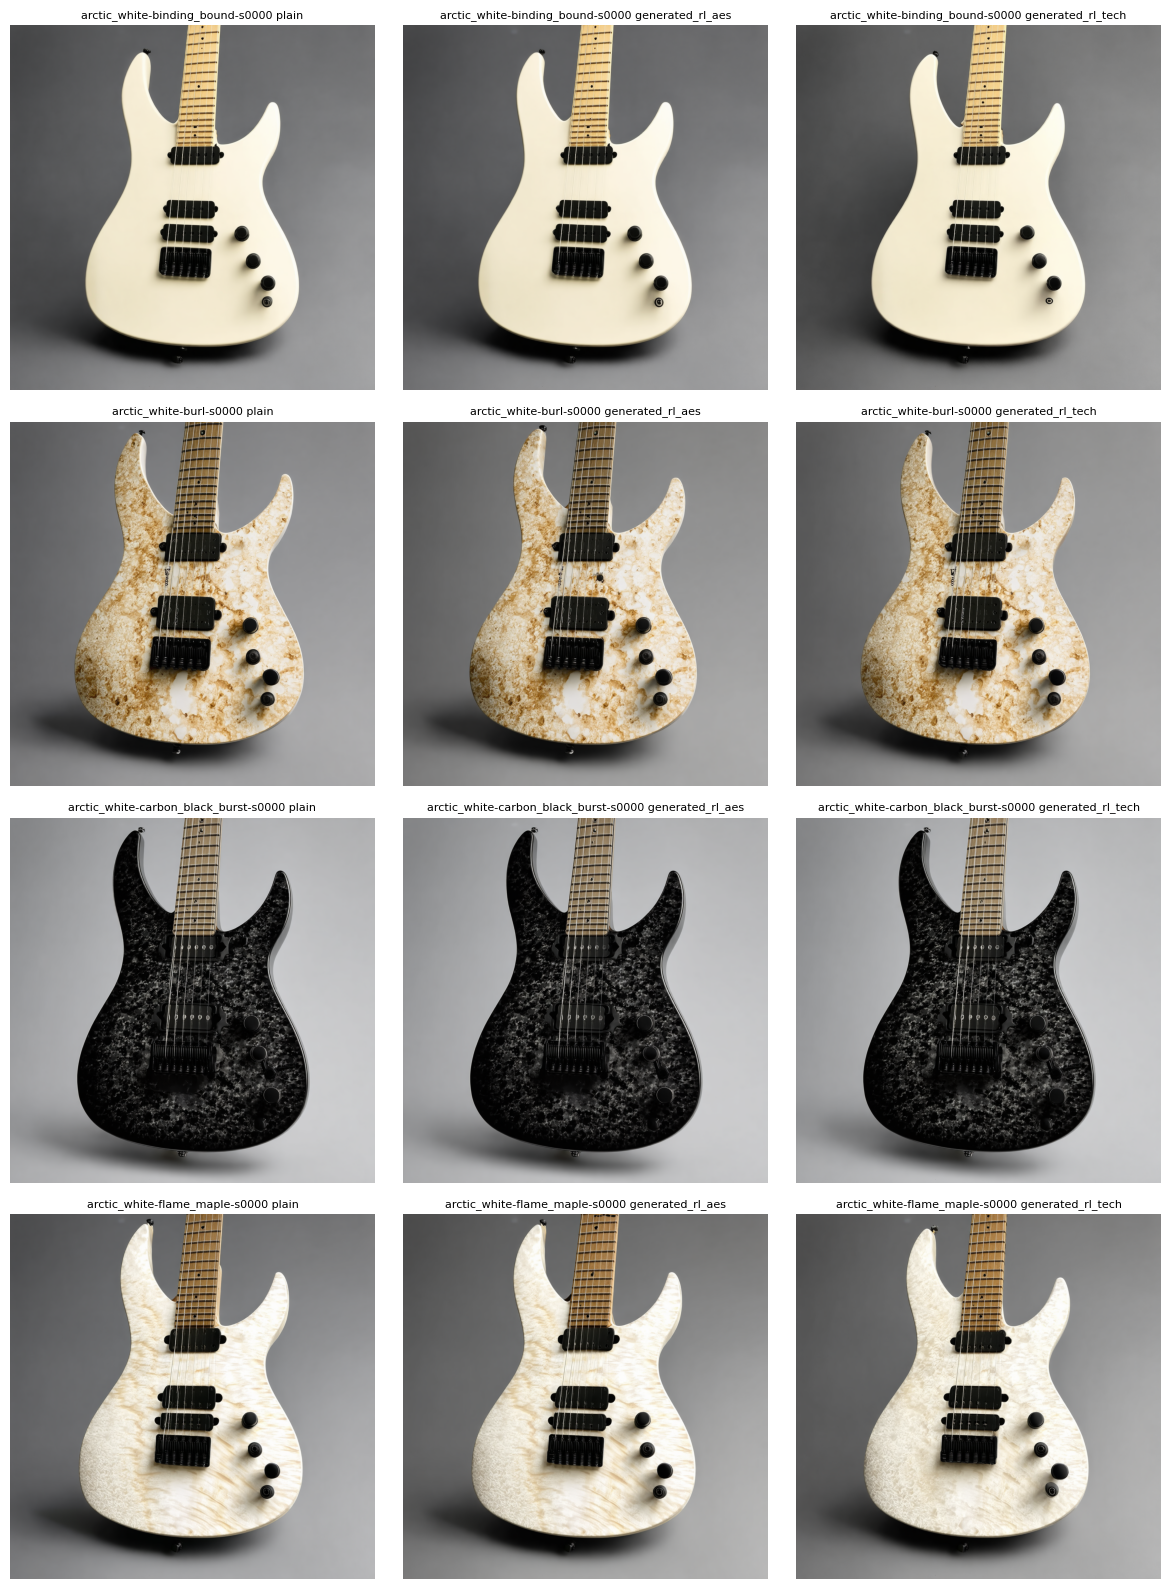

In [24]:
from PIL import Image
import matplotlib.pyplot as plt
tasks = json.load(open(CATALOG))['tasks'][:4]
fig, axs = plt.subplots(len(tasks), 3, figsize=(12, 4 * len(tasks)))
for i, t in enumerate(tasks):
    m = t['meta']
    for j, meth in enumerate(METHODS):
        p = f"{GEN2}/{meth}/{m['model']}/{m['color']}/{m['top']}/seed_{m['seed']:04d}.png"
        if os.path.exists(p): axs[i, j].imshow(Image.open(p))
        axs[i, j].set_title(f"{t['id']} {meth}", fontsize=8); axs[i, j].axis('off')
plt.tight_layout(); plt.show()

## 11. Upload to the bucket

`combinations.json` URLs: `rufgen/generated/SD35/…` (plain), `rufgen/generated_rl_aes/SD35/…`, `rufgen/generated_rl_tech/SD35/…`.
Uncomment to replace the v1 bucket content with v2 (the survey then shows the consistent set).

In [25]:
# bucket in the COMPANY project (mos-eval/deploy/BUCKET-FIRMOWY.md); authenticate with the company account
BUCKET = 'rufai-471714-images'
# from google.colab import auth; auth.authenticate_user()
# !gcloud config set project rufai-471714
# !gcloud storage rsync -r {GEN2} gs://{BUCKET}/rufgen/generated_v2